In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("laptop_prices_data_analysis.csv")
df = pd.DataFrame(data)
df.head()

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650


In [3]:
# checking how many rows and columns are there in the dataset
df.shape

(10000, 23)

In [4]:
# checking datatype for all the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               10000 non-null  object 
 1   Product               10000 non-null  object 
 2   TypeName              10000 non-null  object 
 3   Inches                10000 non-null  float64
 4   Ram                   10000 non-null  int64  
 5   OS                    10000 non-null  object 
 6   Weight                10000 non-null  float64
 7   Price_euros           10000 non-null  float64
 8   Screen                10000 non-null  object 
 9   ScreenW               10000 non-null  int64  
 10  ScreenH               10000 non-null  int64  
 11  Touchscreen           10000 non-null  object 
 12  IPSpanel              10000 non-null  object 
 13  RetinaDisplay         10000 non-null  object 
 14  CPU_company           10000 non-null  object 
 15  CPU_freq            

In [5]:
# Is there any null values in the dataset?
df.isnull().sum()

Company                 0
Product                 0
TypeName                0
Inches                  0
Ram                     0
OS                      0
Weight                  0
Price_euros             0
Screen                  0
ScreenW                 0
ScreenH                 0
Touchscreen             0
IPSpanel                0
RetinaDisplay           0
CPU_company             0
CPU_freq                0
CPU_model               0
PrimaryStorage          0
SecondaryStorage        0
PrimaryStorageType      0
SecondaryStorageType    0
GPU_company             0
GPU_model               0
dtype: int64

In [6]:
# finding duplicates in the dataset 
df.duplicated().sum()

np.int64(0)

In [7]:
df.head()

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650


In [8]:
# Featuring Engineering Process 


In [9]:
# renaming column name 
df = df.rename(columns={'Ram': 'Ram(GB)'})
df = df.rename(columns={'TypeName': 'Type_Name'})
df = df.rename(columns={'Price_euros': 'Price_Euros'})
df = df.rename(columns={'IPSpanel': 'IPS_Panel'})
df = df.rename(columns={'RetinaDisplay': 'Retina_Display'})
df = df.rename(columns={'CPU_company': 'CPU_Company'})
df = df.rename(columns={'CPU_freq': 'CPU_Frequency'})
df = df.rename(columns={'CPU_model': 'CPU_Model'})
df = df.rename(columns={'PrimaryStorage': 'Primary_Storage'})
df = df.rename(columns={'SecondaryStorage': 'Secondary_Storage'})
df = df.rename(columns={'PrimaryStorageType': 'Primary_Storage_Type'})
df = df.rename(columns={'SecondaryStorageType': 'Secondary_Storage_Type'})
df = df.rename(columns={'GPU_company': 'GPU_Company'})
df = df.rename(columns={'GPU_model': 'GPU_Model'})
df = df.rename(columns={'Weight': 'Weight(KG)'})
df = df.rename(columns={'ScreenW': 'Screen_Width'})
df = df.rename(columns={'ScreenH': 'Screen_Height'})
df = df.rename(columns={'Touchscreen': 'Touch_Screen'})

In [10]:
df['Price_Euros'].min()

np.float64(159.46)

In [11]:
df['Price_Euros'].max()

np.float64(6686.78)

In [12]:
# Making price category column
def price_category(price):
    if price <= 600:
        return "Budget"
    elif price <= 1200:
        return "Mid-Range"
    elif price <= 2000:
        return "Upper Mid-Range"
    elif price <= 3500:
        return "Premium"
    else:
        return "Luxury"

df["Price_Category"] = df["Price_Euros"].apply(price_category)

# .apply runs the price_category in every row
# one by one for each price in the column

In [13]:
df['Ram(GB)'].unique()

array([ 8, 16,  4,  2, 12,  6, 32, 24, 64])

In [14]:
# Making RAM category column
def ram_category(ram):
    if ram <= 8:
        return "Low"
    elif ram <= 16:
        return "Medium"
    else:
        return "High"

df["RAM_Category"] = df["Ram(GB)"].apply(ram_category)


In [15]:
df.columns

Index(['Company', 'Product', 'Type_Name', 'Inches', 'Ram(GB)', 'OS',
       'Weight(KG)', 'Price_Euros', 'Screen', 'Screen_Width', 'Screen_Height',
       'Touch_Screen', 'IPS_Panel', 'Retina_Display', 'CPU_Company',
       'CPU_Frequency', 'CPU_Model', 'Primary_Storage', 'Secondary_Storage',
       'Primary_Storage_Type', 'Secondary_Storage_Type', 'GPU_Company',
       'GPU_Model', 'Price_Category', 'RAM_Category'],
      dtype='object')

In [16]:
# Making new column weather the laptop is gaming or not 
gaming_keywords = [
    'gtx',    # NVIDIA dedicated gaming
    'rtx',    # NVIDIA dedicated gaming
    'rx'      # AMD dedicated gaming
]

df['Gaming_Laptop'] = np.where(
    df['GPU_Model'].str.lower().str.contains('|'.join(gaming_keywords), na=False),
    'Yes',
    'No'
)


In [17]:
df.head(10)

,Company,Product,Type_Name,Inches,Ram(GB),OS,Weight(KG),Price_Euros,Screen,Screen_Width,...,CPU_Model,Primary_Storage,Secondary_Storage,Primary_Storage_Type,Secondary_Storage_Type,GPU_Company,GPU_Model,Price_Category,RAM_Category,Gaming_Laptop
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640,Upper Mid-Range,Low,No
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000,Mid-Range,Low,No
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620,Budget,Low,No
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Core i7,512,0,SSD,No,AMD,Radeon Pro 455,Premium,Medium,No
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650,Upper Mid-Range,Low,No
5,Acer,Aspire 3,Notebook,15.6,4,Windows 10,2.10,400.00,Standard,1366,...,A9-Series 9420,500,0,HDD,No,AMD,Radeon R5,Budget,Low,No
6,Apple,MacBook Pro,Ultrabook,15.4,16,Mac OS X,2.04,2139.97,Standard,2880,...,Core i7,256,0,Flash Storage,No,Intel,Iris Pro Graphics,Premium,Medium,No
7,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,1158.70,Standard,1440,...,Core i5,256,0,Flash Storage,No,Intel,HD Graphics 6000,Mid-Range,Low,No
8,Asus,ZenBook UX430UN,Ultrabook,14.0,16,Windows 10,1.30,1495.00,Full HD,1920,...,Core i7 8550U,512,0,SSD,No,Nvidia,GeForce MX150,Upper Mid-Range,Medium,No
9,Acer,Swift 3,Ultrabook,14.0,8,Windows 10,1.60,770.00,Full HD,1920,...,Core i5 8250U,256,0,SSD,No,Intel,UHD Graphics 620,Mid-Range,Low,No


In [18]:
# BUSINESS PROBLEMS

# Ques 1. What is the average price by RAM size?
avg_price_ram_size = round(df.groupby('Ram(GB)')['Price_Euros'].mean(),2)
print(avg_price_ram_size)

Ram(GB)
2      239.71
4      796.10
6      628.51
8     1172.90
12    1217.48
16    1496.87
24    2182.39
32    1285.99
64    4013.80
Name: Price_Euros, dtype: float64


In [19]:
df['Primary_Storage_Type'].unique()

array(['SSD', 'Flash Storage', 'HDD', 'Hybrid'], dtype=object)

In [20]:
df['Secondary_Storage_Type'].unique()

array(['No', 'HDD', 'SSD', 'Hybrid'], dtype=object)

In [21]:
# Ques 2. What is the price difference between SSD and HDD laptops

# First we'll create a separate column for storage
def storage_category(row):
    primary = row["Primary_Storage_Type"]
    secondary = row["Secondary_Storage_Type"]

    if primary in ["SSD", "Flash Storage"] and secondary == "No":
        return "SSD"
    elif primary == "HDD" and secondary == "No":
        return "HDD"
    else:
        return "Hybrid"

df["Storage_Category"] = df.apply(storage_category, axis=1)

In [22]:
# Then filter only SSD and HDD laptops
storage_df = df[df["Storage_Category"].isin(["SSD", "HDD"])]

In [23]:
# Finding the avg price for both of them
avg_price = round(storage_df.groupby("Storage_Category")["Price_Euros"].mean(),2)
print(avg_price)

Storage_Category
HDD     657.32
SSD    1234.16
Name: Price_Euros, dtype: float64


In [24]:
# what is the avg price between them
price_difference = avg_price["SSD"] - avg_price["HDD"]
print("Average Price Difference:", price_difference)


# Laptops with SSD storage are, on average, 576.84 more expensive than HDD laptops.


Average Price Difference: 576.84


In [25]:
# Check distribution
df["CPU_Company"].value_counts()

CPU_Company
Intel      9516
AMD         477
Samsung       7
Name: count, dtype: int64

In [26]:
# Ques 3. How does CPU brand (Intel vs AMD) affect price?

# Filter Intel and AMD only
cpu_df = df[df["CPU_Company"].isin(["Intel", "AMD"])]

In [27]:
# calculating avg price by CPU company
avg_price_cpu = round(cpu_df.groupby("CPU_Company")["Price_Euros"].mean(),2)
print(avg_price_cpu)

CPU_Company
AMD       586.00
Intel    1166.83
Name: Price_Euros, dtype: float64


In [28]:
# Calculating price difference 
price_difference = round(avg_price_cpu["Intel"] - avg_price_cpu["AMD"],2)
print("Average Price Difference:", price_difference)

# conclusion
# Laptops with Intel processors are, on average, 580.83 more expensive than laptops with AMD processors.

Average Price Difference: 580.83


In [29]:
# Ques 4. Does GPU presence increase price?

# creating GPU separate column
def gpu_presence(gpu_company):
    if gpu_company in ["Nvidia", "AMD"]:
        return "Dedicated GPU"
    else:
        return "Integrated GPU"

df["GPU_Presence"] = df["GPU_Company"].apply(gpu_presence)


In [30]:
# checking distribution
df["GPU_Presence"].value_counts()

GPU_Presence
Integrated GPU    5511
Dedicated GPU     4489
Name: count, dtype: int64

In [31]:
# calculating avg price 
avg_price_gpu = round(df.groupby("GPU_Presence")["Price_Euros"].mean(),2)
print(avg_price_gpu)


GPU_Presence
Dedicated GPU     1283.00
Integrated GPU    1021.28
Name: Price_Euros, dtype: float64


In [32]:
# finding avg price 
price_difference = avg_price_gpu["Dedicated GPU"] - avg_price_gpu["Integrated GPU"]
print("Average Price Difference:", price_difference)

# conclusion 
# Laptops with dedicated GPUs are, on average, 261.72 more expensive than laptops with integrated GPUs.

Average Price Difference: 261.72


In [33]:
# Ques 5. What is the average laptop price by brand
brand_avg_price = round(df.groupby('Company')['Price_Euros'].mean(),2).sort_values(ascending=False)
print(brand_avg_price)

Company
Razer        3124.46
LG           2096.32
MSI          1720.89
Google       1667.19
Microsoft    1584.03
Apple        1564.23
Samsung      1433.76
Huawei       1411.49
Toshiba      1312.11
Dell         1205.63
Xiaomi       1148.79
Asus         1129.04
Lenovo       1105.32
HP           1067.46
Fujitsu       732.65
Acer          646.19
Chuwi         329.74
Mediacom      294.72
Vero          218.92
Name: Price_Euros, dtype: float64


In [34]:
# Ques 6. What is the minimum and maximum price per brand
brand_prices = df.groupby('Company')['Price_Euros'].agg(['min', 'max']).sort_values(ascending=False, by=['min', 'max'])
print(brand_prices)

               min      max
Company                    
LG         1717.61  2378.62
Huawei     1279.95  1552.61
Google     1152.26  2400.95
Razer       933.53  6686.78
Microsoft   920.55  2815.07
Xiaomi      847.98  1534.43
Apple       845.19  3064.74
MSI         756.61  3018.90
Fujitsu     590.03   844.32
Toshiba     403.82  2897.18
Dell        247.86  3973.48
Samsung     245.33  1914.24
Lenovo      224.31  5099.27
Chuwi       221.91   491.23
Mediacom    221.71   417.56
HP          191.89  4809.18
Vero        180.21   284.22
Asus        175.20  4344.11
Acer        159.46  2831.71


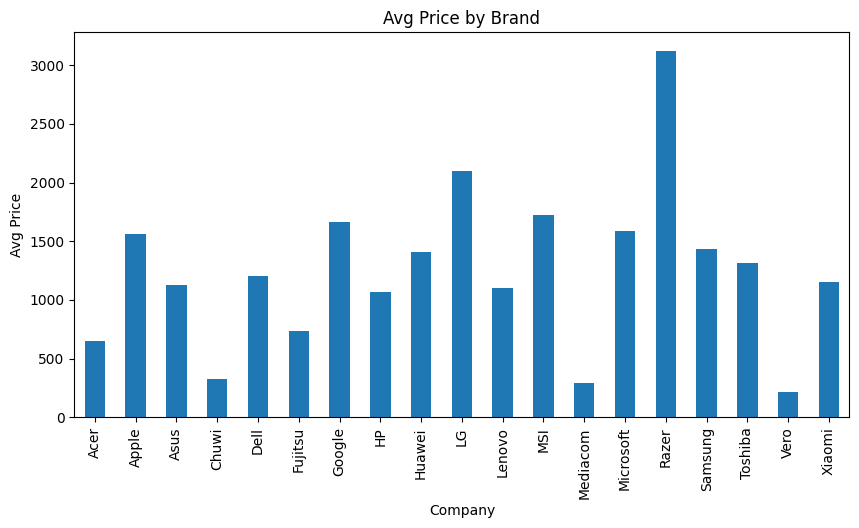

In [35]:
# Ques 7. What is the Price distribution across brands
brand_prices = round(df.groupby('Company')['Price_Euros'].mean(),2)

# creating chart
brand_prices.plot.bar(x='Company', y='Price', title = 'Avg Price by Brand', figsize = (10,5))
plt.ylabel('Avg Price')
plt.show()

In [36]:
# Ques 8. What the average price between SSD vs HDD vs Hybrid

# For this we have to combine both the columns
def storage_category(row):
    primary = row["Primary_Storage_Type"]
    secondary = row["Secondary_Storage_Type"]

    if primary in ["SSD", "Flash Storage"] and secondary == "No":
        return "SSD"
    elif primary == "HDD" and secondary == "No":
        return "HDD"
    else:
        return "Hybrid"

df["Storage_Category_two"] = df.apply(storage_category, axis=1)


In [37]:
# How many values these contain
df["Storage_Category_two"].value_counts()

Storage_Category_two
SSD       5550
HDD       2711
Hybrid    1739
Name: count, dtype: int64

In [38]:
# Now what is the avg price 
avg_price_storage = round(df.groupby("Storage_Category_two")["Price_Euros"].mean(),2)
print(avg_price_storage)

# conclusion
# Hybrid laptops are the most expensive on average, followed by SSD laptops, while HDD laptops are the cheapest.

Storage_Category_two
HDD        657.32
Hybrid    1584.87
SSD       1234.16
Name: Price_Euros, dtype: float64


In [39]:
df.columns

Index(['Company', 'Product', 'Type_Name', 'Inches', 'Ram(GB)', 'OS',
       'Weight(KG)', 'Price_Euros', 'Screen', 'Screen_Width', 'Screen_Height',
       'Touch_Screen', 'IPS_Panel', 'Retina_Display', 'CPU_Company',
       'CPU_Frequency', 'CPU_Model', 'Primary_Storage', 'Secondary_Storage',
       'Primary_Storage_Type', 'Secondary_Storage_Type', 'GPU_Company',
       'GPU_Model', 'Price_Category', 'RAM_Category', 'Gaming_Laptop',
       'Storage_Category', 'GPU_Presence', 'Storage_Category_two'],
      dtype='object')

In [40]:
# Ques 9. Is there any Correlation between laptop weight and price?

correlation = df["Weight(KG)"].corr(df["Price_Euros"])
print("Correlation between Weight and Price:", correlation)

Correlation between Weight and Price: 0.2068811735469622


In [42]:
# Ques 10.Are lightweight laptops more expensive?
 
df["Weight_Category"] = df["Weight(KG)"].apply(
    lambda x: "Lightweight" if x <= 1.8 else "Heavyweight"
)

In [43]:
# checking distribution
df["Weight_Category"].value_counts()

Weight_Category
Heavyweight    6363
Lightweight    3637
Name: count, dtype: int64

In [44]:
# calculating avg price 
avg_price_weight = round(df.groupby("Weight_Category")["Price_Euros"].mean(),2)
print(avg_price_weight)


Weight_Category
Heavyweight    1086.30
Lightweight    1230.55
Name: Price_Euros, dtype: float64


In [45]:
# comparing prices 
price_difference = (
    avg_price_weight["Lightweight"]
    - avg_price_weight["Heavyweight"]
)

print("Average Price Difference:", price_difference)

# conclusion 
# Lightweight laptops are, on average, more expensive than heavyweight laptops, indicating that portability comes at a premium.


Average Price Difference: 144.25


In [46]:
pip install gradio pandas matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# saving file 
df.to_csv('laptop_price_analysis.csv', index=False)

In [53]:
import gradio as gr
import pandas as pd
import plotly.express as px

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("laptop_price_analysis.csv")

px.defaults.template = "plotly_dark"
GOLD = "#FFD700"

# =========================
# FILTER FUNCTION
# =========================
def filter_data(brand, cpu, gpu):
    data = df.copy()
    if brand and brand != "All":
        data = data[data["Company"] == brand]
    if cpu and cpu != "All":
        data = data[data["CPU_Company"] == cpu]
    if gpu and gpu != "All":
        data = data[data["GPU_Company"] == gpu]
    return data


# =========================
# PAGE 1 – EXECUTIVE OVERVIEW
# =========================
def executive_overview(brand, cpu, gpu):
    data = filter_data(brand, cpu, gpu)
    if data.empty:
        return "No Data", "", "", "", "", None, None, None

    total = len(data)
    avg_price = data["Price_Euros"].mean()
    cheapest = data.loc[data["Price_Euros"].idxmin()]
    expensive = data.loc[data["Price_Euros"].idxmax()]
    avg_storage = data["Primary_Storage"].mean()

    kpi_total = f"<h3>Total Laptops</h3><h2>{total:,}</h2>"
    kpi_avg = f"<h3>Average Price</h3><h2>€ {avg_price:,.2f}</h2>"
    kpi_cheapest = f"<h3>Cheapest</h3><h2>{cheapest['Company']}</h2><p>€ {cheapest['Price_Euros']:,.2f}</p>"
    kpi_expensive = f"<h3>Most Expensive</h3><h2>{expensive['Company']}</h2><p>€ {expensive['Price_Euros']:,.2f}</p>"
    kpi_storage = f"<h3>Avg Storage (GB)</h3><h2>{avg_storage:,.2f}</h2>"

    brand_avg = data.groupby("Company", as_index=False)["Price_Euros"].mean().round(2)
    fig1 = px.bar(brand_avg, x="Company", y="Price_Euros",
                  text="Price_Euros",
                  title="Average Price by Brand")
    fig1.update_traces(texttemplate="%{text:.2f}",
                       textposition="outside",
                       textfont=dict(color="white"),
                       marker_color=GOLD)

    fig2 = px.pie(data, names="CPU_Company",
                  title="Laptop Distribution by CPU")
    fig2.update_traces(textinfo="percent+label",
                       textfont=dict(size=13))

    fig3 = px.treemap(data,
                      path=["Price_Category"],
                      values="Price_Euros",
                      title="Distribution by Price Category")

    return kpi_total, kpi_avg, kpi_cheapest, kpi_expensive, kpi_storage, fig1, fig2, fig3


# =========================
# PAGE 2 – HARDWARE IMPACT
# =========================
def hardware_impact(brand, cpu, gpu):
    data = filter_data(brand, cpu, gpu)
    if data.empty:
        return None, None, None, None, None

    cpu_avg = data.groupby("CPU_Company", as_index=False)["Price_Euros"].mean().round(2)
    fig1 = px.bar(cpu_avg, x="CPU_Company", y="Price_Euros",
                  text="Price_Euros",
                  title="Average Price by CPU Company")
    fig1.update_traces(texttemplate="%{text:.2f}",
                       textposition="outside",
                       textfont=dict(color="white"),
                       marker_color=GOLD)

    gpu_avg = data.groupby("GPU_Presence", as_index=False)["Price_Euros"].mean().round(2)
    fig2 = px.bar(gpu_avg, x="GPU_Presence", y="Price_Euros",
                  text="Price_Euros",
                  title="Average Price by GPU Presence")
    fig2.update_traces(texttemplate="%{text:.2f}",
                       textposition="outside",
                       textfont=dict(color="white"),
                       marker_color=GOLD)

    ram_avg = data.groupby("Ram(GB)", as_index=False)["Price_Euros"].mean().round(2)
    fig3 = px.line(ram_avg, x="Ram(GB)", y="Price_Euros",
                   markers=True,
                   title="Average Price by RAM (GB)")
    fig3.update_traces(texttemplate="%{y:.2f}",
                       textposition="top center",
                       textfont=dict(color="white"),
                       line_color=GOLD)

    fig4 = px.histogram(data,
                        x="CPU_Company",
                        color="GPU_Company",
                        barmode="stack",
                        title="CPU vs GPU Company")

    ram_cat = data.groupby("RAM_Category", as_index=False)["Price_Euros"].mean().round(2)
    fig5 = px.bar(ram_cat, x="RAM_Category", y="Price_Euros",
                  text="Price_Euros",
                  title="Average Price by RAM Category")
    fig5.update_traces(texttemplate="%{text:.2f}",
                       textposition="outside",
                       textfont=dict(color="white"),
                       marker_color=GOLD)

    return fig1, fig2, fig3, fig4, fig5


# =========================
# PAGE 3 – PORTABILITY & STORAGE
# =========================
def portability_view(brand, cpu, gpu):
    data = filter_data(brand, cpu, gpu)
    if data.empty:
        return None, None, None

    table = data[["Company", "Ram(GB)", "Primary_Storage", "Price_Category"]].head(25)

    weight_avg = data.groupby("Weight_Category", as_index=False)["Price_Euros"].mean().round(2)
    fig1 = px.bar(weight_avg,
                  x="Weight_Category",
                  y="Price_Euros",
                  text="Price_Euros",
                  title="Average Price by Weight")
    fig1.update_traces(texttemplate="%{text:.2f}",
                       textposition="outside",
                       textfont=dict(color="white"),
                       marker_color=GOLD)

    storage_weight = data.groupby(
        ["Primary_Storage_Type", "Weight_Category"],
        as_index=False)["Price_Euros"].sum().round(2)

    fig2 = px.bar(storage_weight,
                  x="Primary_Storage_Type",
                  y="Price_Euros",
                  color="Weight_Category",
                  barmode="group",
                  text="Price_Euros",
                  title="Price by Storage Type & Weight")
    fig2.update_traces(texttemplate="%{text:.2f}",
                       textposition="outside",
                       textfont=dict(color="white"))

    return table, fig1, fig2


# =========================
# UI
# =========================
brands = ["All"] + sorted(df["Company"].unique())
cpus = ["All"] + sorted(df["CPU_Company"].unique())
gpus = ["All"] + sorted(df["GPU_Company"].unique())

with gr.Blocks(css="""
body {background:linear-gradient(135deg,#0f0f0f,#1c1c1c);}
.kpi {
    background:linear-gradient(145deg,#1e1e1e,#2a2a2a);
    border-radius:18px;
    padding:22px;
    height:160px;
    text-align:center;
    color:white;
    box-shadow:0 10px 30px rgba(0,0,0,0.6);
    border:1px solid rgba(255,215,0,0.4);
    transition:0.3s;
}
.kpi:hover {
    transform:translateY(-6px);
    box-shadow:0 15px 35px rgba(255,215,0,0.5);
}
.kpi h2 {color:#FFD700;font-size:30px;}
""") as app:

    gr.Markdown("# 💻 Laptop Price Analysis Dashboard")

    with gr.Row():
        brand = gr.Dropdown(brands, value="All", label="Brand")
        cpu = gr.Dropdown(cpus, value="All", label="CPU Company")
        gpu = gr.Dropdown(gpus, value="All", label="GPU Company")

    with gr.Tabs():

        with gr.Tab("Executive Overview"):
            with gr.Row():
                k1 = gr.HTML(elem_classes="kpi")
                k2 = gr.HTML(elem_classes="kpi")
                k3 = gr.HTML(elem_classes="kpi")
                k4 = gr.HTML(elem_classes="kpi")
                k5 = gr.HTML(elem_classes="kpi")

            f1 = gr.Plot()
            f2 = gr.Plot()
            f3 = gr.Plot()

        with gr.Tab("Hardware Impact"):
            hf1, hf2, hf3, hf4, hf5 = gr.Plot(), gr.Plot(), gr.Plot(), gr.Plot(), gr.Plot()

        with gr.Tab("Portability & Storage"):
            table = gr.Dataframe()
            pf1 = gr.Plot()
            pf2 = gr.Plot()

    # Auto update
    brand.change(executive_overview, [brand,cpu,gpu], [k1,k2,k3,k4,k5,f1,f2,f3])
    cpu.change(executive_overview, [brand,cpu,gpu], [k1,k2,k3,k4,k5,f1,f2,f3])
    gpu.change(executive_overview, [brand,cpu,gpu], [k1,k2,k3,k4,k5,f1,f2,f3])

    brand.change(hardware_impact, [brand,cpu,gpu], [hf1,hf2,hf3,hf4,hf5])
    cpu.change(hardware_impact, [brand,cpu,gpu], [hf1,hf2,hf3,hf4,hf5])
    gpu.change(hardware_impact, [brand,cpu,gpu], [hf1,hf2,hf3,hf4,hf5])

    brand.change(portability_view, [brand,cpu,gpu], [table,pf1,pf2])
    cpu.change(portability_view, [brand,cpu,gpu], [table,pf1,pf2])
    gpu.change(portability_view, [brand,cpu,gpu], [table,pf1,pf2])

    app.load(executive_overview, [brand,cpu,gpu], [k1,k2,k3,k4,k5,f1,f2,f3])
    app.load(hardware_impact, [brand,cpu,gpu], [hf1,hf2,hf3,hf4,hf5])
    app.load(portability_view, [brand,cpu,gpu], [table,pf1,pf2])

app.launch()


C:\Users\pundir\AppData\Local\Temp\ipykernel_6152\4027832072.py:168: UserWarning:

The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.



* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.
